In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import the requested clustering algorithms
from sklearn.cluster import AffinityPropagation, SpectralClustering, DBSCAN, OPTICS, Birch, MeanShift, estimate_bandwidth

# Setup plot styles
sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
# Load the dataset
dataset = pd.read_csv('Mall_Customers.csv')

# Extract Annual Income (Column 3) and Spending Score (Column 4)
X = dataset.iloc[:, [3, 4]].values

print(f"Dataset shape: {dataset.shape}")
print(f"Feature matrix shape: {X.shape}")
dataset.head()

Dataset shape: (200, 5)
Feature matrix shape: (200, 2)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
dataset.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [4]:
df = pd.DataFrame(X, columns=['Annual Income', 'Spending Score'])

### Affinity propagation

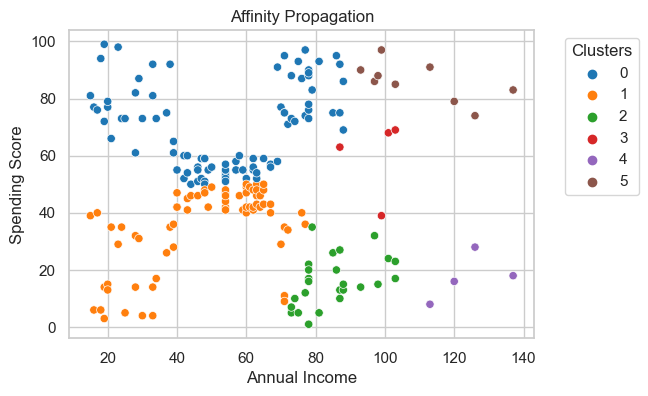

In [6]:
# Initialize and fit Affinity Propagation
# damping control message updates (0.5 to 1.0); random_state keeps results stable
# Calculate the similarity matrix to find a custom low preference value
from sklearn.metrics.pairwise import euclidean_distances
# We use negative distances because Affinity Propagation expects "similarity" (higher means more similar)
similarities = -euclidean_distances(X)
#min_preference = np.min(similarities)
optimized_preference = np.percentile(similarities, 5)

# Initialize Affinity Propagation with a lower preference
# Using min_preference forces fewer, larger clusters
ap_optimized = AffinityPropagation(damping=0.95, preference=optimized_preference, random_state=42)
df['Cluster_AP'] = ap_optimized.fit_predict(X)

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Annual Income', y='Spending Score', hue='Cluster_AP', palette='tab10')
plt.title('Affinity Propagation')
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [7]:
print(f"Number of clusters found by Affinity Propagation: {len(np.unique(df['Cluster_AP']))}")

Number of clusters found by Affinity Propagation: 6


In [8]:
df

,Annual Income,Spending Score,Cluster_AP
0,15,39,1
1,15,81,0
2,16,6,1
3,16,77,0
4,17,40,1
...,...,...,...
195,120,79,5
196,126,28,4
197,126,74,5
198,137,18,4


#### Spectral Clustering

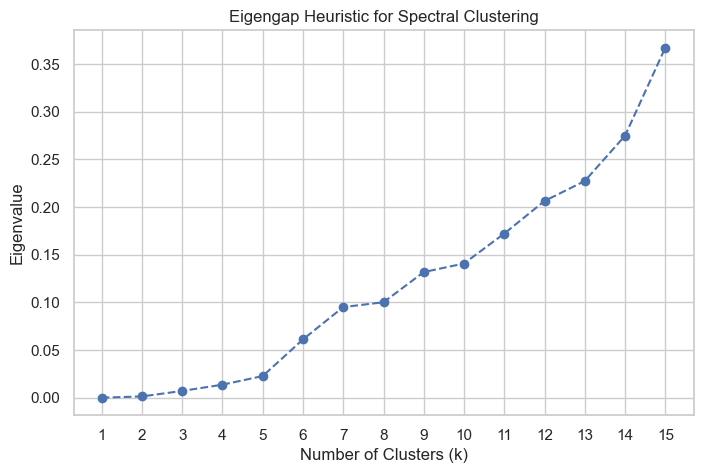

In [10]:
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import laplacian

# 1. Construct the adjacency matrix (graph representation of data)
# We look at nearest neighbors to see how points connect to each other
connectivity = kneighbors_graph(X, n_neighbors=10, mode='connectivity', include_self=False)
adjacency = 0.5 * (connectivity + connectivity.T) # Make the graph symmetric

# 2. Compute the Graph Laplacian matrix
# 'unnormalized' or 'symmetric' both work well; symmetric is standard for spectral
L = laplacian(adjacency, normed=True)

# 3. Extract and sort the eigenvalues in ascending order
eigenvalues, _ = np.linalg.eigh(L.toarray())

# 4. Plot the eigenvalues to find the optimal "Eigengap"
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, 16), eigenvalues[:15], marker='o', linestyle='--', color='b')
plt.title('Eigengap Heuristic for Spectral Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Eigenvalue')
plt.xticks(np.arange(1, 16))
plt.grid(True)
plt.show()

D:\Anaconda\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


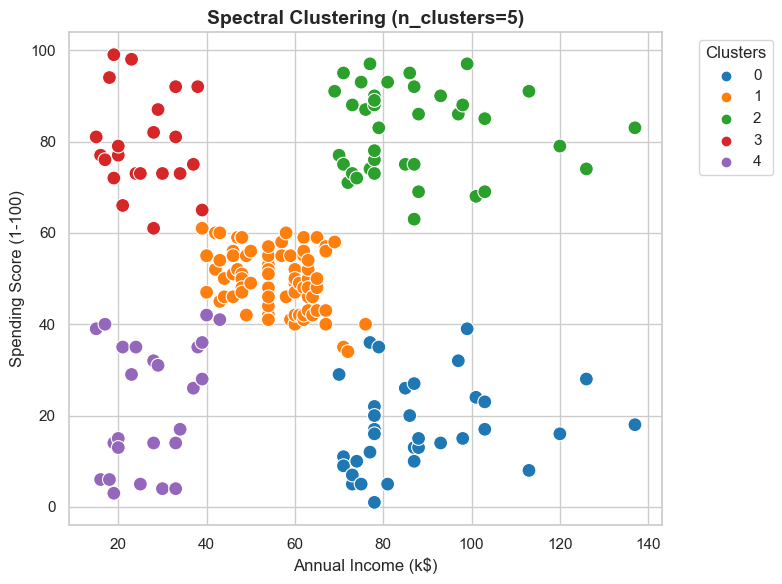

In [11]:
# Build the model using the optimal 5 clusters found from the Eigengap
spectral = SpectralClustering(n_clusters=5, affinity='nearest_neighbors', random_state=42)
df['Cluster_Spectral'] = spectral.fit_predict(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual Income', y='Spending Score', hue='Cluster_Spectral', palette='tab10', s=100)
plt.title('Spectral Clustering (n_clusters=5)', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [12]:
print(f"Number of clusters found by Spectral clustering: {len(np.unique(df['Cluster_Spectral']))}")

Number of clusters found by Spectral clustering: 5


In [13]:
df

,Annual Income,Spending Score,Cluster_AP,Cluster_Spectral
0,15,39,1,4
1,15,81,0,3
2,16,6,1,4
3,16,77,0,3
4,17,40,1,4
...,...,...,...,...
195,120,79,5,2
196,126,28,4,0
197,126,74,5,2
198,137,18,4,0


### DBSCAN

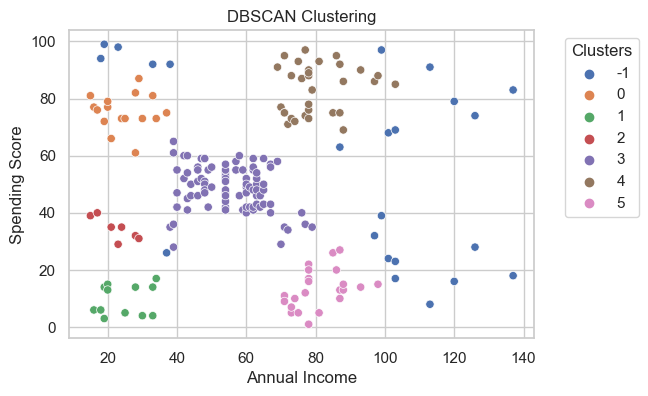

In [15]:
dbscan = DBSCAN(eps=9.0, min_samples=5)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X)

plt.figure(figsize=(6, 4))
# 'palette' will still color everything automatically, including outliers (-1)
sns.scatterplot(data=df, x='Annual Income', y='Spending Score', hue='Cluster_DBSCAN', palette='deep')
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('DBSCAN Clustering')
plt.show()

In [16]:
print(f"Number of clusters found by DBSCAN Clustering: {len(np.unique(df['Cluster_DBSCAN']))}")

Number of clusters found by DBSCAN Clustering: 7


In [17]:
df

,Annual Income,Spending Score,Cluster_AP,Cluster_Spectral,Cluster_DBSCAN
0,15,39,1,4,2
1,15,81,0,3,0
2,16,6,1,4,1
3,16,77,0,3,0
4,17,40,1,4,2
...,...,...,...,...,...
195,120,79,5,2,-1
196,126,28,4,0,-1
197,126,74,5,2,-1
198,137,18,4,0,-1


### OPTICS Algorithm

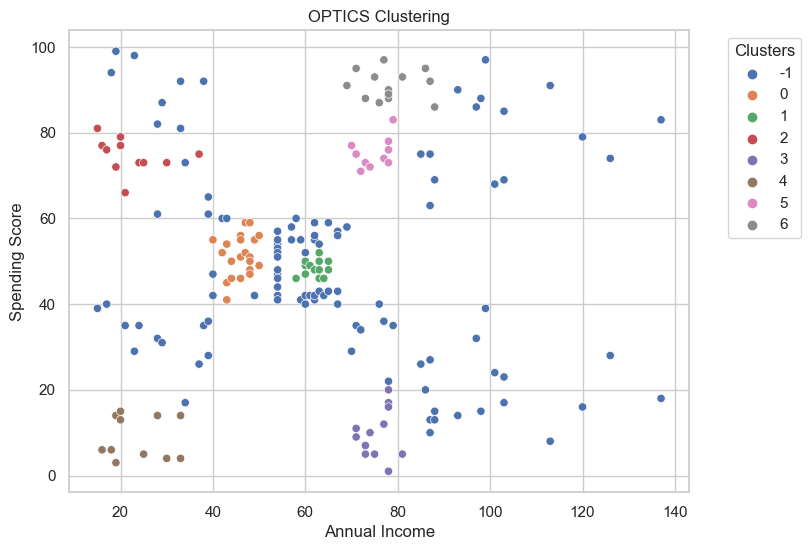

In [19]:
optics = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05)
df['Cluster_optics']= optics.fit_predict(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual Income', y='Spending Score', hue='Cluster_optics', palette='deep')
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('OPTICS Clustering')
plt.show()

In [20]:
print(f"Number of clusters found by OPTICS Clustering: {len(np.unique(df['Cluster_optics']))}")

Number of clusters found by OPTICS Clustering: 8


In [21]:
df

,Annual Income,Spending Score,Cluster_AP,Cluster_Spectral,Cluster_DBSCAN,Cluster_optics
0,15,39,1,4,2,-1
1,15,81,0,3,0,2
2,16,6,1,4,1,4
3,16,77,0,3,0,2
4,17,40,1,4,2,-1
...,...,...,...,...,...,...
195,120,79,5,2,-1,-1
196,126,28,4,0,-1,-1
197,126,74,5,2,-1,-1
198,137,18,4,0,-1,-1


### BIRCH Algorithm

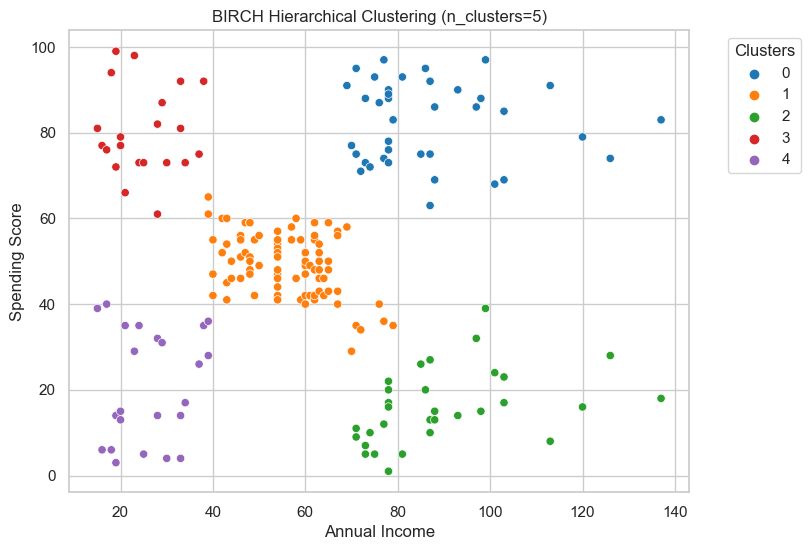

In [23]:
birch = Birch(threshold=1.5, branching_factor=50, n_clusters=5)
df['Cluster_BIRCH'] = birch.fit_predict(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual Income', y='Spending Score', hue='Cluster_BIRCH', palette='tab10')
plt.title('BIRCH Hierarchical Clustering (n_clusters=5)')
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [24]:
print(f"Number of clusters found by BIRCH Clustering: {len(np.unique(df['Cluster_BIRCH']))}")

Number of clusters found by BIRCH Clustering: 5


In [25]:
df

,Annual Income,Spending Score,Cluster_AP,Cluster_Spectral,Cluster_DBSCAN,Cluster_optics,Cluster_BIRCH
0,15,39,1,4,2,-1,4
1,15,81,0,3,0,2,3
2,16,6,1,4,1,4,4
3,16,77,0,3,0,2,3
4,17,40,1,4,2,-1,4
...,...,...,...,...,...,...,...
195,120,79,5,2,-1,-1,0
196,126,28,4,0,-1,-1,2
197,126,74,5,2,-1,-1,0
198,137,18,4,0,-1,-1,2


### Mean Shift Algorithm

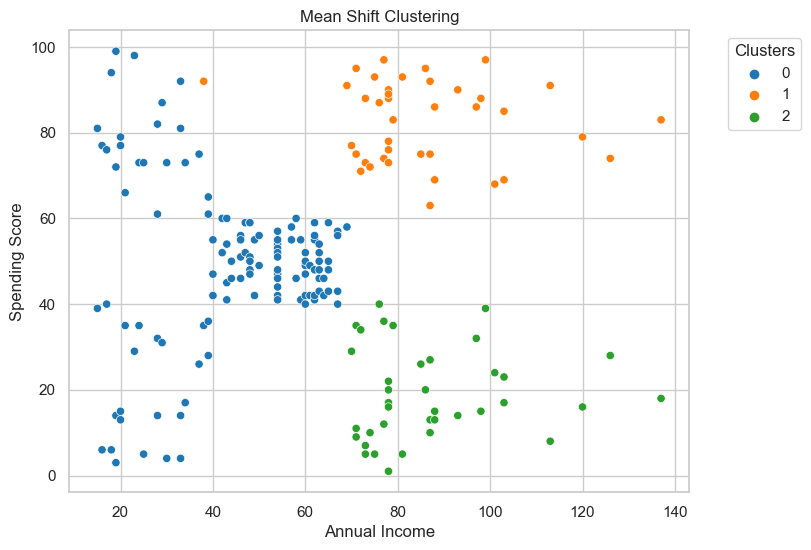

In [27]:
bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=200)
meanshift = MeanShift(bandwidth=bandwidth, bin_seeding=True)
df['Cluster_MEAN_SHIFT'] = meanshift.fit_predict(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual Income', y='Spending Score', hue='Cluster_MEAN_SHIFT', palette='tab10')
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Mean Shift Clustering')
plt.show()

In [28]:
print(f"Number of clusters found by MEAN SHIFT Clustering: {len(np.unique(df['Cluster_MEAN_SHIFT']))}")

Number of clusters found by MEAN SHIFT Clustering: 3


In [29]:
df

,Annual Income,Spending Score,Cluster_AP,Cluster_Spectral,Cluster_DBSCAN,Cluster_optics,Cluster_BIRCH,Cluster_MEAN_SHIFT
0,15,39,1,4,2,-1,4,0
1,15,81,0,3,0,2,3,0
2,16,6,1,4,1,4,4,0
3,16,77,0,3,0,2,3,0
4,17,40,1,4,2,-1,4,0
...,...,...,...,...,...,...,...,...
195,120,79,5,2,-1,-1,0,1
196,126,28,4,0,-1,-1,2,2
197,126,74,5,2,-1,-1,0,1
198,137,18,4,0,-1,-1,2,2


## The Spectral and BIRCH clustering algorithms were able form optimal clusters